# Time Series Monitoring of Aquatic Weeds and Floating Algae

* **Products used:** 
[wq_annual](https://explorer.digitalearth.africa/products/wq_annual), 
[ls5_sr](https://explorer.digitalearth.africa/products/ls5_sr),
[ls7_sr](https://explorer.digitalearth.africa/products/ls7_sr),
[ls8_sr](https://explorer.digitalearth.africa/products/ls8_sr),
[ls9_sr](https://explorer.digitalearth.africa/products/ls9_sr),
[s2_l2a](https://explorer.digitalearth.africa/products/s2_l2a)

## Background
This notebook is part of a collection of water quality (WQ) analysis notebooks that use Earth observation data to assess surface water conditions. 
Combined, these notebooks provide a more holistic view of water quality by enabling analysis across multiple indicators.

This notebook focuses on the __Floating Algae Index (FAI)__.

The [Water Quality Monitoring Service (WQMS) dataset notebook](https://github.com/digitalearthafrica/deafrica-sandbox-notebooks/blob/main/Datasets/Water_Quality.ipynb) introduces the several variables available in the _annual_ water quality product. 
However, one may want to monitor these variables on shorter time scales, as we do with FAI in this notebook.

A widespread phenomenon on inland waters is the presence of photsynthesising algae, including cyanobacteria, and/or aquatic weeds such as [Water Hyacinth](https://www.arc.agric.za/arc-ppri/Pages/Water-hyacinth.aspx). These can be monitored using DE Africa data and services, and published remote sensing algorithms. 

Water Hyacinth is particularly reported to be a problem in Rift Valley lakes, including parts of Lake Victoria such as around the Port of Kisumu, and is a well-known problem in Hartbeespoort Dam, South Africa.

![Hyacinth at Hartbeespoort Dam](https://thebulrushes-media-content-af-south1.s3.af-south-1.amazonaws.com/wp-content/uploads/2023/12/20110204/hartbeespoort-dam-hyacinth_53407817255_o.jpg)

**Figure 1:** *Hyacinth at Hartbeespoort Dam ([source](https://thebulrushes.com/2025/07/17/magalies-water-reduces-water-hyacinth-at-hartbeespoort-dam/)).*

The **Floating Algae Index (FAI)** can be used to map and quantify the extent of these phenomena. FAI is sensitive to photosynthetic surface material (PSM) on the water surface. It can be applied using data from the Sentinel-2 MSI, Landsat OLI, and Landsat TM sensors. Used together, MSI and OLI provide over 100 observations per year, while TM provides historical continuity back to the early 2000s. These observations, when combined with Digital Earth Africa (DE Africa) products such as the [Water Observations from Space (WOfS)](https://docs.digitalearthafrica.org/en/latest/data_specs/Water_Observations_from_Space.html), Geomedian composites, and Waterbodies products, can capture dynamic surface processes and quantify the percentage of water area affected.

### FAI

The FAI detects unexpectedly high values of near infrared (NIR) reflectance, by comparing the NIR value reflectance with the value that would be expected given the Red, and short-wave infrared (SWIR) reflectances. The approach takes into account the specific central wavelenghts of the sensor bands. This means that FAI is more able to support multi-sensor approaches than other measures and indices which assume identical sensor characteristics.

The interpolated NIR is given by:

$$
\text{Interpolated NIR} =
\text{Red} +
(\text{SWIR} - \text{Red}) \cdot
\frac{\lambda_{\text{NIR}} - \lambda_{\text{Red}}}{\lambda_{\text{SWIR}} - \lambda_{\text{Red}}}
$$

The Floating Algae Index is then defined as:

$$
\text{FAI} = \text{Observed NIR} - \text{Interpolated NIR}
$$

### Reference

Hu, C. (2009). *A novel ocean color index to detect floating algae in the global oceans*. https://doi.org/10.1016/j.rse.2009.05.012

## Description
Digital Earth Africa enables long-term monitoring of waterbodies through the [annual water quality data](https://explorer.digitalearth.africa/products/wq_annual) and short-term monitoring by providing functionality to apply algorithms to the source observational data. In this notebook, we:

1. [Load in annual data](#Load-in-annual-data)
2. [Load the source observational data](#Load-the-source-observational-data)
3. [Derive FAI values for the source observational data](#Derive-FAI-values-for-the-source-observational-data)
4. [Calculate the proportion of water area that is affected](#Calculate-the-proportion-of-water-area-that-is-affected)
5. [Produce a meaningful graph](#Calculate-the-proportion-of-water-area-that-is-affected)

***

## Getting started

Provide any particular instructions that the user might need, e.g. To run this analysis, run all the cells in the notebook, starting with the "Load packages" cell. 

### Load packages
Import Python packages that are used for the analysis.

To import the `water_quality` package, please first run `git clone -b develop https://github.com/digitalearthafrica/deafrica_water_quality.git` in the terminal and update the path below to point to it.

In [1]:
%matplotlib inline

import datacube
import xarray as xr
import matplotlib.pyplot as plt

from deafrica_tools.plotting import display_map
from deafrica_tools.datahandling import load_ard

import sys

sys.path.append("/home/jovyan/deafrica_water_quality/src")
from water_quality.mapping.fai import FAI

### Connect to the datacube

Connect to the datacube so we can access DE Africa data.
The `app` parameter is a unique name for the analysis which is based on the notebook file name.

In [2]:
dc = datacube.Datacube(app="FAI_monitoring")

## Load in annual data
We load in the annual Floating Algae Index data from the DE Africa Water Quality Monitoring Service (WQMS). 
The default location is Hartbeespoort Dam in South Africa.

In [3]:
query = {
    "x": (27.78, 27.91),
    "y": (-25.78, -25.72),
    "time": ("2020-01-01", "2025-12-31"),
}

In [4]:
display_map(x=query["x"], y=query["y"])

In [5]:
ds_annual = dc.load(
    product="wq_annual",
    x=query["x"],
    y=query["y"],
    time=query["time"],
    measurements=["water_mask", "agm_fai"],
    resolution=(-10, 10),
    output_crs="epsg:6933",
)

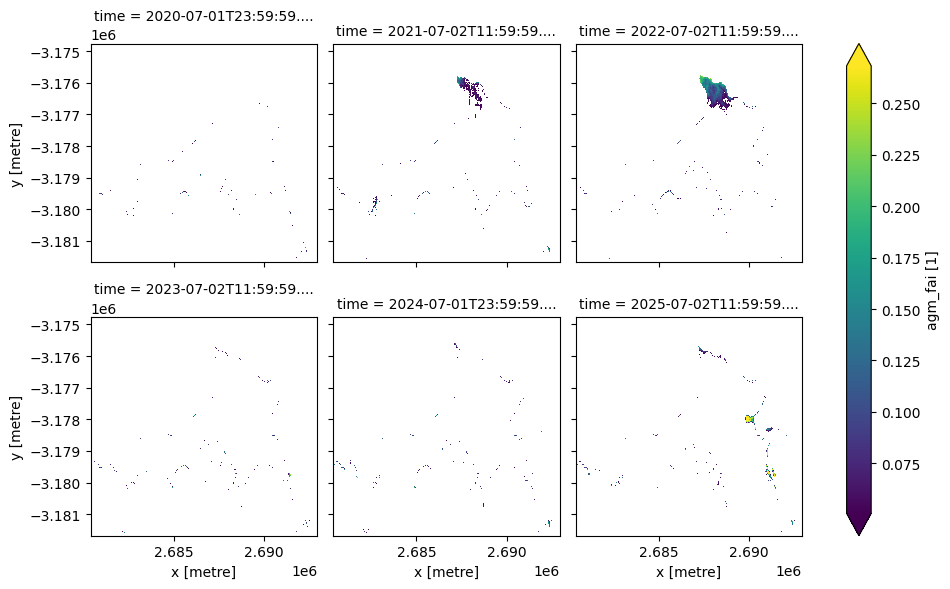

In [6]:
ds_annual.agm_fai.plot.imshow(robust=True, col="time", col_wrap=3);

### Load the source observational data
For short-term monitoring we load in the full set of observations available in DE Africa from the Thematic Mapper (TM; Landsat 5 and 7), Operational Land Imager (OLI; Landsat 8 and 9) and Multispectral Imager (MSI; Sentinel-2) sensors.

In [7]:
# Map load_ard measurements into those needed by the water_quality package per sensor
measurements = {
    "oli": {"red": "oli04", "nir": "oli05", "swir_1": "oli06", "pixel_quality": "pq"},
    "msi": {"red": "msi04", "nir_narrow": "msi8a", "swir_1": "msi11", "qa": "qa"},
    "tm": {"red": "tm03", "nir": "tm04", "swir_1": "tm05", "pixel_quality": "pq"},
}

In [8]:
# Map sensors to products
products = {
    "tm": ["ls5_sr", "ls7_sr"],
    "oli": ["ls8_sr", "ls9_sr"],
    "msi": ["s2_l2a"],
}

Next, we load in the data at 60m resolution for 2023-2024.

In [9]:
ds_list = {}

for ins in products.keys():
    ds_list[ins] = load_ard(
        dc,
        products=products[ins],
        x=query["x"],
        y=query["y"],
        time=("2023-01-01", "2024-12-31"),
        measurements=list(measurements[ins].keys()),
        output_crs="epsg:6933",
        resolution=(-60, 60),
        group_by="solar_day",
        min_gooddata=0.2,
        verbose=True,
        dask_chunks={},
    ).rename(measurements[ins])

/opt/venv/lib/python3.12/site-packages/deafrica_tools/datahandling.py:245: UserWarning: Setting 'min_gooddata' percentage to > 0.0 will cause dask arrays to compute when loading pixel-quality data to calculate 'good pixel' percentage. This can slow the return of your dataset.
  warnings.warn(


Using pixel quality parameters for USGS Collection 2
Finding datasets
    ls5_sr
    ls7_sr
Counting good quality pixels for each time step
Filtering to 19 out of 20 time steps with at least 20.0% good quality pixels
Applying pixel quality/cloud mask
Re-scaling Landsat C2 data
Returning 19 time steps as a dask array
Using pixel quality parameters for USGS Collection 2
Finding datasets
    ls8_sr


/opt/venv/lib/python3.12/site-packages/deafrica_tools/datahandling.py:565: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds = xr.merge([ds_data, ds_masks])
/opt/venv/lib/python3.12/site-packages/deafrica_tools/datahandling.py:245: UserWarning: Setting 'min_gooddata' percentage to > 0.0 will cause dask arrays to compute when loading pixel-quality data to calculate 'good pixel' percentage. This can slow the return of your dataset.
  warnings.warn(


    ls9_sr
Counting good quality pixels for each time step
Filtering to 132 out of 164 time steps with at least 20.0% good quality pixels
Applying pixel quality/cloud mask
Re-scaling Landsat C2 data
Returning 132 time steps as a dask array
Using pixel quality parameters for Sentinel 2
Finding datasets
    s2_l2a


/opt/venv/lib/python3.12/site-packages/deafrica_tools/datahandling.py:565: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds = xr.merge([ds_data, ds_masks])
/opt/venv/lib/python3.12/site-packages/deafrica_tools/datahandling.py:245: UserWarning: Setting 'min_gooddata' percentage to > 0.0 will cause dask arrays to compute when loading pixel-quality data to calculate 'good pixel' percentage. This can slow the return of your dataset.
  warnings.warn(


Counting good quality pixels for each time step


/opt/venv/lib/python3.12/site-packages/rasterio/warp.py:385: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dest = _reproject(


Filtering to 228 out of 290 time steps with at least 20.0% good quality pixels
Applying pixel quality/cloud mask
Returning 228 time steps as a dask array


### Derive FAI values for the source observational data

In [10]:
fai_list = []

for ins in products.keys():
    fai_list.append(FAI(ds_list[ins], ins))

### Calculate the proportion of water area that is affected
First, we specify a threshold of 0.05 above which to 'detect' FAI to calculate FAI cover. This threshold is chosen since FAI values above 0.05 are unlikely to be noise.

In [11]:
fai_threshold = 0.05

In [12]:
# Concat FAI across sensors
fai = xr.concat(fai_list, dim="time").sortby("time")

In [13]:
# Compute the monthly mean FAI
fai_monthly = fai.resample(time="ME").mean().compute()

In [14]:
# Align the annual water to the monthly data's spatio-temporal dimensions
water_mask_aligned = ds_annual.water_mask.reindex_like(fai_monthly, method="nearest")

In [15]:
# Calculate where the monthly data is above the threshold and in the water mask
fai_monthly = fai_monthly.where(fai_monthly > fai_threshold).where(
    water_mask_aligned == 1
)

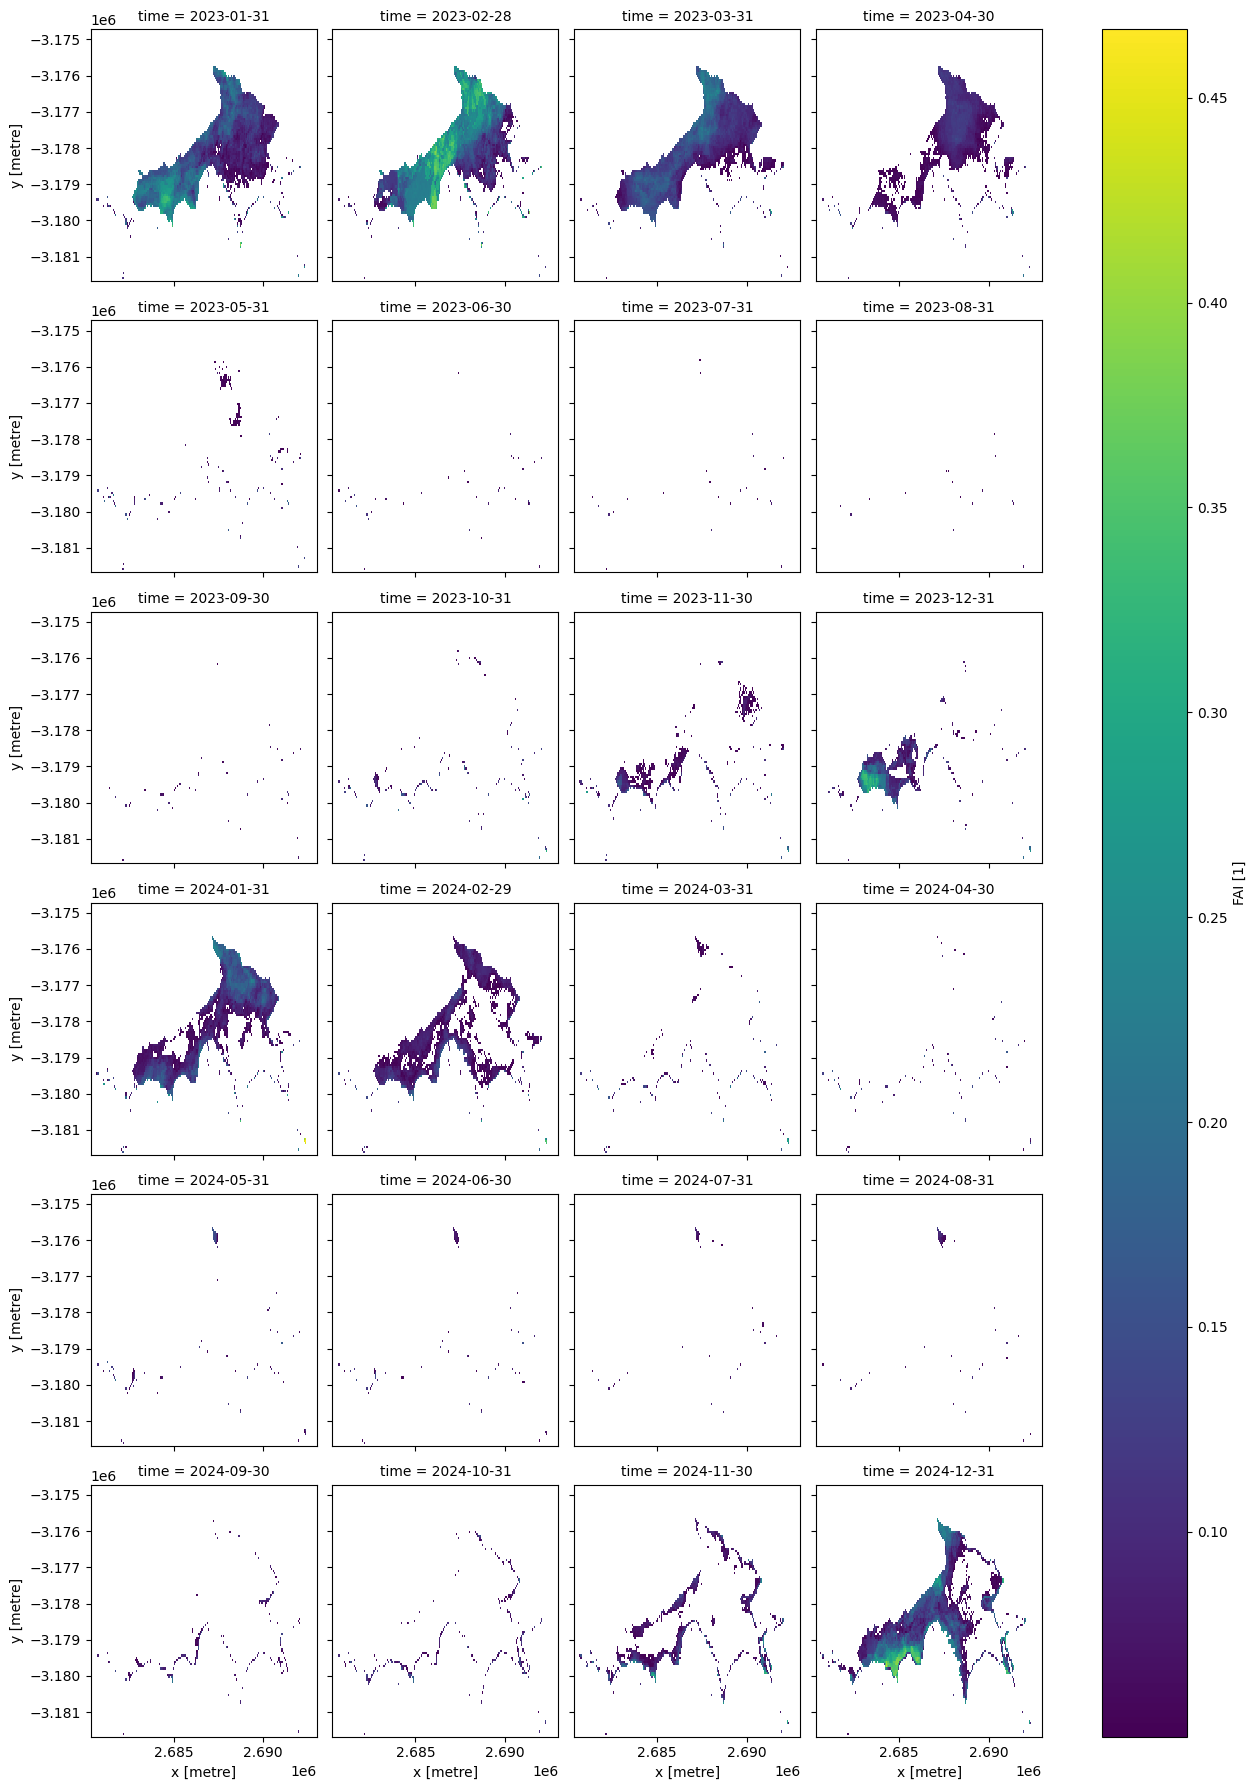

In [16]:
# Visualise the data
fai_monthly.plot.imshow(col="time", col_wrap=4);

In [17]:
# Calculate FAI cover as pixels detected above FAI threshold, divided by total number of pixels, expressed as a percentage
fai_cover = (
    (fai_monthly.count(dim=("x", "y")) / water_mask_aligned.count(dim=("x", "y"))) * 100
).round(2)

In [18]:
# Convert results to a dataframe
monthly_results = (
    fai_cover.reset_coords("spatial_ref", drop=True)
    .to_dataframe(name="fai_cover")
    .reset_index()
)

In [19]:
ds_annual["fai_cover_percent"] = (
    (
        ds_annual.agm_fai.count(dim=("x", "y"))
        / ds_annual.water_mask.count(dim=("x", "y"))
    )
    * 100
).round(2)

In [20]:
annual_results = (
    ds_annual[["fai_cover_percent"]]
    .reset_coords("spatial_ref", drop=True)
    .to_dataframe()
    .reset_index()
)
annual_results["year"] = annual_results["time"].dt.year

### Produce a meaningful graph
As seen in the graph below, the annual FAI cover is lower since it represents the fraction of area for which FAI values above 0.05 were typical for that year. 
In contrast, the monthly estimates show higher variability, capturing short-term changes in FAI conditions.

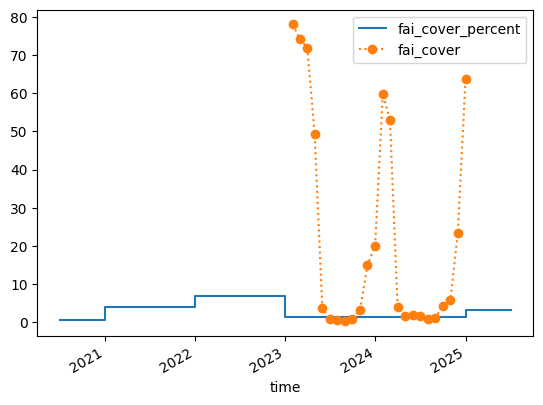

In [21]:
fig, ax = plt.subplots(1, 1)
annual_results.plot(x="time", y="fai_cover_percent", drawstyle="steps-mid", ax=ax)
monthly_results.plot(x="time", y="fai_cover", linestyle=":", marker="o", ax=ax);

***

## Additional information

**License:** The code in this notebook is licensed under the [Apache License, Version 2.0](https://www.apache.org/licenses/LICENSE-2.0). 
Digital Earth Africa data is licensed under the [Creative Commons by Attribution 4.0](https://creativecommons.org/licenses/by/4.0/) license.

**Contact:** If you need assistance, please post a question on the [Open Data Cube Slack channel](http://slack.opendatacube.org/) or on the [GIS Stack Exchange](https://gis.stackexchange.com/questions/ask?tags=open-data-cube) using the `open-data-cube` tag (you can view previously asked questions [here](https://gis.stackexchange.com/questions/tagged/open-data-cube)).
If you would like to report an issue with this notebook, you can file one on [Github](https://github.com/digitalearthafrica/deafrica-sandbox-notebooks).

**Compatible datacube version:** 

In [22]:
print(datacube.__version__)

1.9.13


**Last Tested:**

In [23]:
from datetime import datetime

datetime.today().strftime("%Y-%m-%d")

'2026-03-24'